# DART40 previous-vs-new obs_diag check

This notebook compares only the two requested DART40 diagnostic files over their common time interval.


In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

RUN_NAME = "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy"
OBS_DIAG_DIR = Path(
    "/compyfs/zhan391/v3_dart_cda_scratch"
) / RUN_NAME / "archive/dart_en40/dart_diagnostics/obs_diag"

PREVIOUS_DIAG_FILE = OBS_DIAG_DIR / (
    f"{RUN_NAME}.dart.e.eam_obs_diag_output.2011120100-2012010100.nc"
)
NEW_DIAG_FILE = OBS_DIAG_DIR / (
    f"{RUN_NAME}.dart.e.eam_obs_diag_output.2011120100-2011120500.nc"
)

REGION = "Northern Hemisphere"
XMIN, XMAX = 0, 4
RTOL, ATOL = 1e-7, 0.0

PLOT_VARIABLES = [
    "RADIOSONDE_U_WIND_COMPONENT",
    "RADIOSONDE_V_WIND_COMPONENT",
    "RADIOSONDE_TEMPERATURE",
    "RADIOSONDE_SPECIFIC_HUMIDITY",
]
# choices are ['962-1035 hPa', '887-962 hPa', '775-887 hPa', '600-775 hPa', 
#              '450-600 hPa', '350-450 hPa', '275-350 hPa', '225-275 hPa', 
#              '175-225 hPa', '125-175 hPa', '75-125 hPa', '35-75 hPa', 
#              '15-35 hPa', '2-15 hPa']
PLOT_LEVELS = ["962-1035 hPa", '775-887 hPa', "450-600 hPa", "225-275 hPa"]

SHOW = True
SAVE = True
FIGURE_DIR = Path(
    "/compyfs/www/zhan391/e3sm_dart/diag_out/figure"
) / "dart40_previous_vs_new"


In [22]:
def _check_files():
    for file_path in (PREVIOUS_DIAG_FILE, NEW_DIAG_FILE):
        if not file_path.is_file():
            raise FileNotFoundError(file_path)


def _strings(values):
    values = np.asarray(values)
    return [
        value.decode("utf-8").strip()
        if isinstance(value, (bytes, np.bytes_))
        else str(value).strip()
        for value in values
    ]


def compare_overlapping_diagnostics(rtol=RTOL, atol=ATOL):
    # Compare every shared diagnostic array on coordinates present in both files.
    _check_files()
    rows = []

    with xr.open_dataset(PREVIOUS_DIAG_FILE, decode_times=False) as previous, xr.open_dataset(
        NEW_DIAG_FILE, decode_times=False
    ) as new:
        names = sorted(
            name
            for name in set(previous.data_vars).intersection(new.data_vars)
            if name.endswith(("_guess", "_VPguess", "_guess_RankHist"))
        )

        for name in names:
            old, regenerated = xr.align(previous[name], new[name], join="inner")
            old_values = np.asarray(old.values)
            new_values = np.asarray(regenerated.values)
            close = np.isclose(
                old_values,
                new_values,
                rtol=rtol,
                atol=atol,
                equal_nan=True,
            )
            difference = np.abs(old_values - new_values)
            finite = difference[np.isfinite(difference)]

            rows.append({
                "variable": name,
                "overlap_shape": old_values.shape,
                "different_values": int(close.size - np.count_nonzero(close)),
                "max_abs_difference": (
                    float(finite.max()) if finite.size else np.nan
                ),
                "mean_abs_difference": (
                    float(finite.mean()) if finite.size else np.nan
                ),
            })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["different_values", "max_abs_difference"],
            ascending=False,
        )
        .reset_index(drop=True)
    )


In [23]:
difference_summary = compare_overlapping_diagnostics()
display(difference_summary)


,variable,overlap_shape,different_values,max_abs_difference,mean_abs_difference
0,GPSRO_REFRACTIVITY_guess_RankHist,"(17, 41, 14, 5)",30519,44.0,2.345440
1,RADIOSONDE_V_WIND_COMPONENT_guess_RankHist,"(17, 41, 14, 5)",24092,30.0,1.246526
2,AIRS_TEMPERATURE_guess_RankHist,"(17, 41, 14, 5)",24024,28.0,1.178684
3,RADIOSONDE_U_WIND_COMPONENT_guess_RankHist,"(17, 41, 14, 5)",23772,30.0,1.205247
4,RADIOSONDE_TEMPERATURE_guess_RankHist,"(17, 41, 14, 5)",20734,23.0,1.029781
...,...,...,...,...,...
56,MARINE_SFC_SPECIFIC_HUMIDITY_guess,"(17, 23, 1, 5)",0,0.0,0.000000
57,MARINE_SFC_TEMPERATURE_guess,"(17, 23, 1, 5)",0,0.0,0.000000
58,MARINE_SFC_U_WIND_COMPONENT_guess,"(17, 23, 1, 5)",0,0.0,0.000000
59,MARINE_SFC_V_WIND_COMPONENT_guess,"(17, 23, 1, 5)",0,0.0,0.000000


In [24]:
def _pressure_labels(ds):
    edges = np.asarray(ds["plevel_edges"].values)
    return [
        f"{int(edges[index + 1])}-{int(edges[index])} hPa"
        for index in range(ds.sizes["plevel"])
    ]


def _metric_series(ds, variable, region_index, level_index):
    copies = {
        name: index
        for index, name in enumerate(_strings(ds["CopyMetaData"].values))
    }
    data = ds[f"{variable}_guess"].isel(
        region=region_index,
        plevel=level_index,
    )

    rmse = data.isel(copy=copies["rmse"])
    spread = data.isel(copy=copies["totalspread"])
    nposs = data.isel(copy=copies["Nposs"])
    nused = data.isel(copy=copies["Nused"])

    return {
        "RMSE": rmse,
        "Spread / RMSE": xr.where(rmse != 0, spread / rmse, np.nan),
        "Rejection (%)": xr.where(
            nposs > 0,
            100.0 - 100.0 * nused / nposs,
            np.nan,
        ),
    }


def plot_level_comparison(level_label, show=SHOW, save=SAVE):
    _check_files()
    datasets = {
        "Previous diag": xr.open_dataset(PREVIOUS_DIAG_FILE, decode_times=False),
        "New diag": xr.open_dataset(NEW_DIAG_FILE, decode_times=False),
    }

    try:
        metrics = {}
        for label, ds in datasets.items():
            region_names = _strings(ds["region_names"].values)
            if REGION not in region_names:
                raise ValueError(
                    f"{REGION!r} is unavailable; choices are {region_names}"
                )
            level_names = _pressure_labels(ds)
            if level_label not in level_names:
                raise ValueError(
                    f"{level_label!r} is unavailable; choices are {level_names}"
                )

            metrics[label] = {
                variable: _metric_series(
                    ds, variable, region_names.index(REGION),
                    level_names.index(level_label),
                )
                for variable in PLOT_VARIABLES
            }

        metric_names = list(metrics[next(iter(metrics))][PLOT_VARIABLES[0]])
        column_labels = ["U", "V", "T", "Q"]
        fig, axes = plt.subplots(
            len(metric_names), len(PLOT_VARIABLES),
            figsize=(20, 12), sharex=True, squeeze=False,
        )
        for column, (variable, column_label) in enumerate(
            zip(PLOT_VARIABLES, column_labels)
        ):
            axes[0, column].set_title(column_label)
            for row, metric_name in enumerate(metric_names):
                axis = axes[row, column]
                has_valid_data = False
                for label, ds_metrics in metrics.items():
                    values = ds_metrics[variable][metric_name]
                    relative_time = (
                        np.asarray(values["time"]) - float(values["time"][0])
                    )
                    mask = (relative_time >= XMIN) & (relative_time <= XMAX)
                    plotted_values = np.asarray(values)[mask]
                    has_valid_data |= bool(np.isfinite(plotted_values).any())
                    axis.plot(
                        relative_time[mask], plotted_values,
                        marker="o", label=label,
                    )
                if not has_valid_data:
                    axis.text(
                        0.5, 0.5, "No valid observations",
                        ha="center", va="center",
                        transform=axis.transAxes, color="0.4",
                    )
                axis.grid(alpha=0.25)
                axis.set_xlim(XMIN, XMAX)
                if column == 0:
                    axis.set_ylabel(metric_name)
                if row == len(metric_names) - 1:
                    axis.set_xlabel("Days since 2011-12-01")

        axes[0, 0].legend()
        fig.suptitle(f"{level_label} | {REGION}", fontsize=16)
        fig.tight_layout(rect=(0, 0, 1, 0.97))

        if save:
            FIGURE_DIR.mkdir(parents=True, exist_ok=True)
            output = FIGURE_DIR / f"UVTQ_{level_label.replace(' ', '')}.pdf"
            fig.savefig(output, dpi=300, bbox_inches="tight")
            print(f"Saved {output}")
        if show:
            plt.show()
        else:
            plt.close(fig)
    finally:
        for ds in datasets.values():
            ds.close()


Saved /compyfs/www/zhan391/e3sm_dart/diag_out/figure/dart40_previous_vs_new/UVTQ_962-1035hPa.pdf


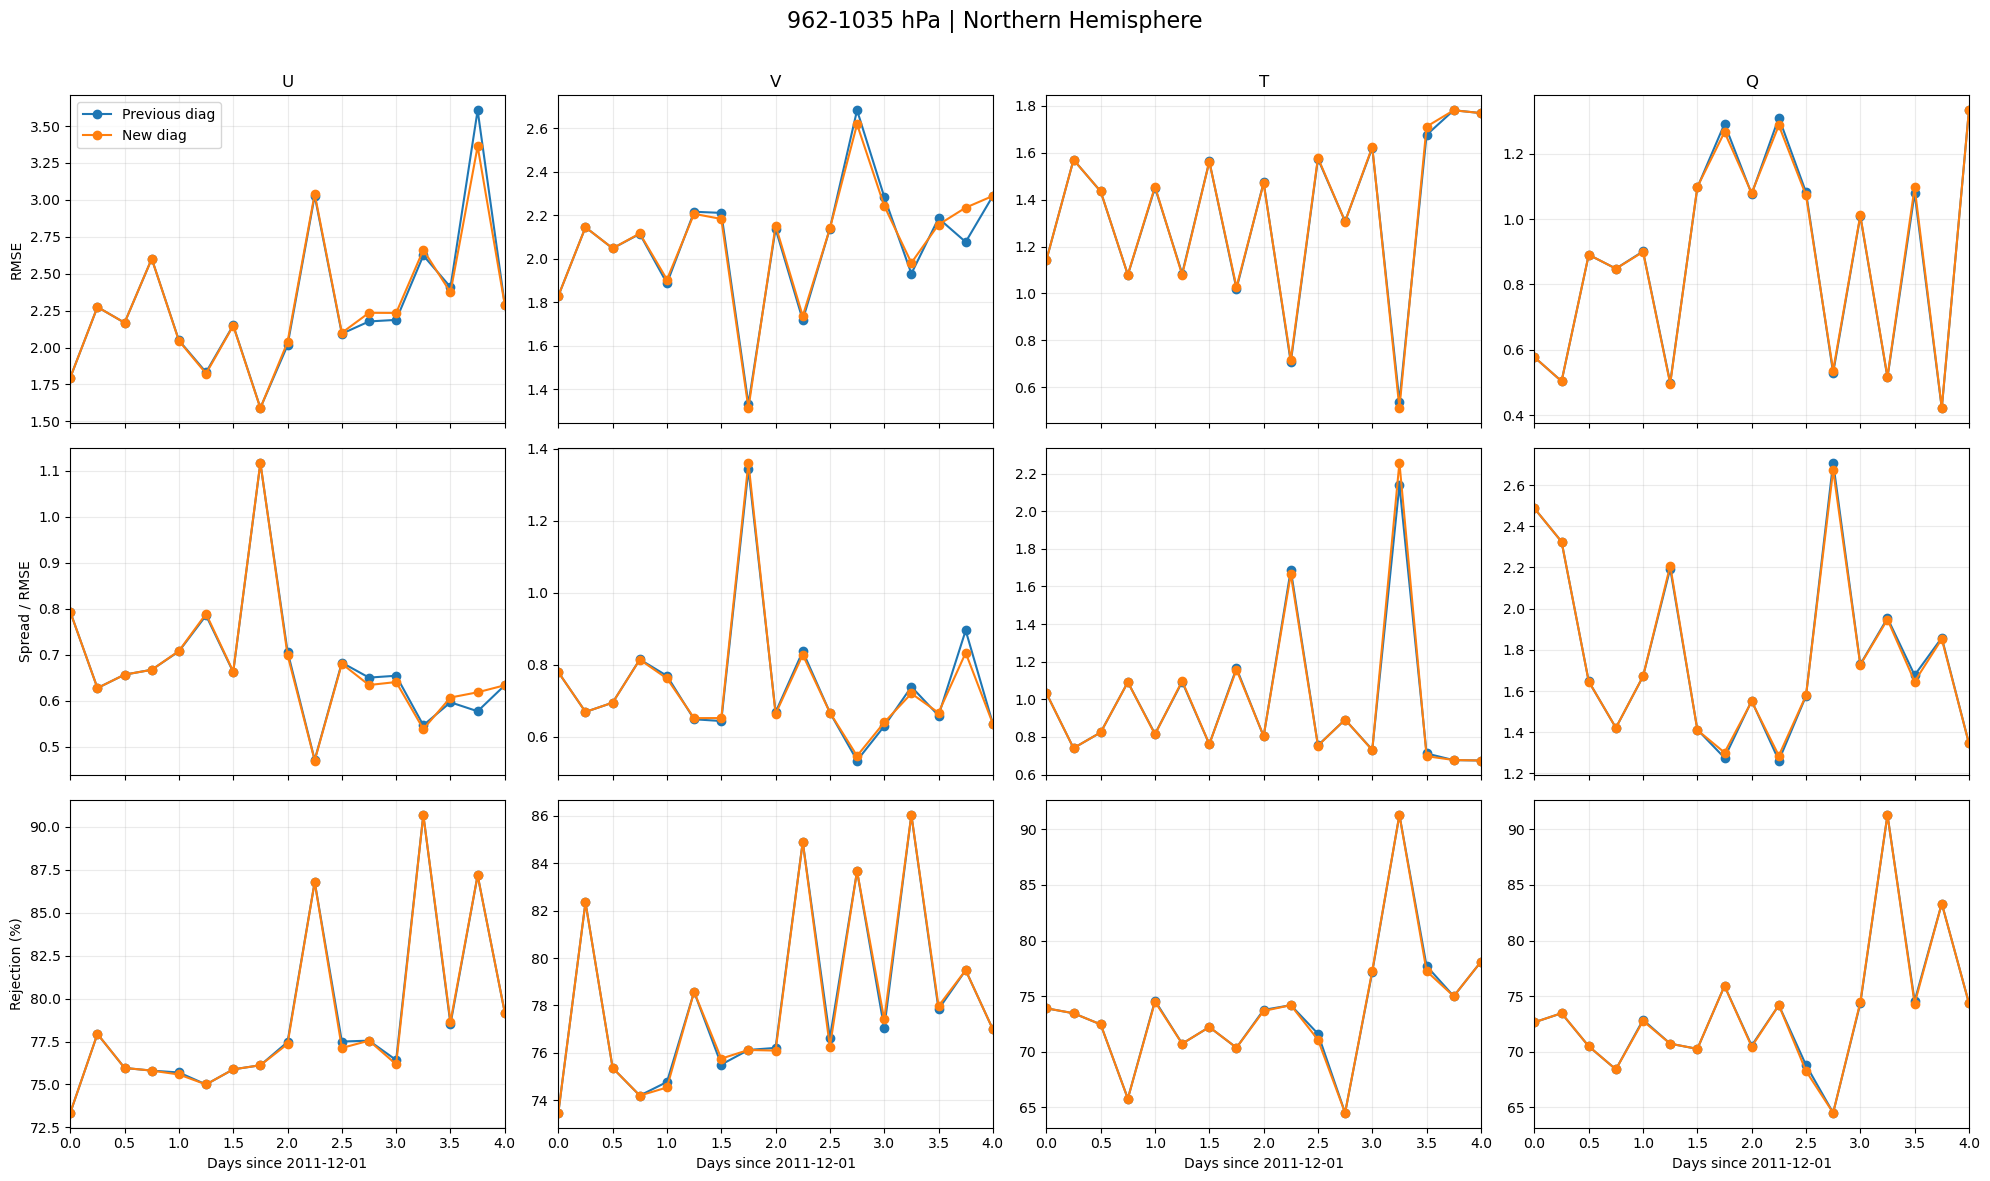

Saved /compyfs/www/zhan391/e3sm_dart/diag_out/figure/dart40_previous_vs_new/UVTQ_775-887hPa.pdf


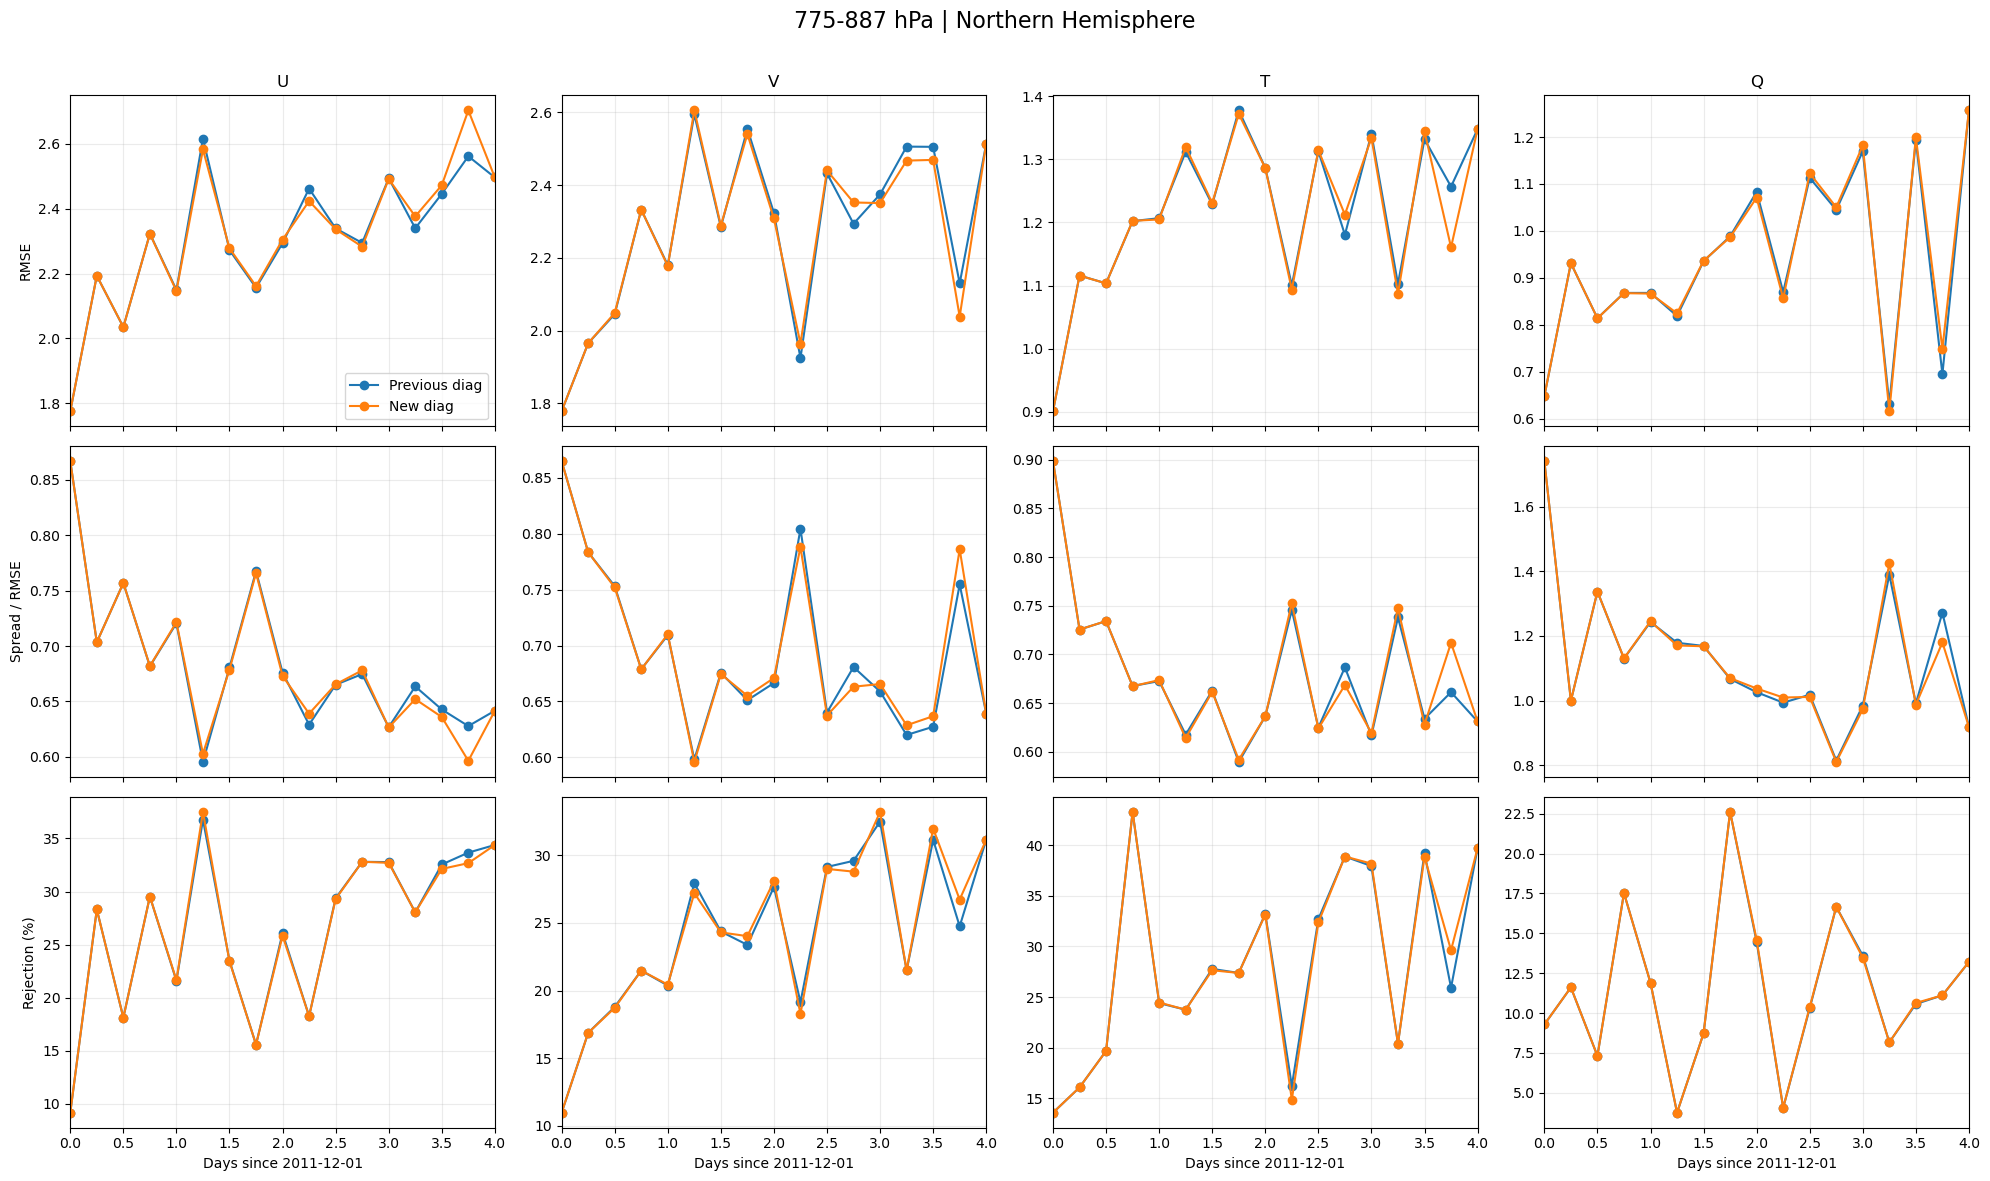

Saved /compyfs/www/zhan391/e3sm_dart/diag_out/figure/dart40_previous_vs_new/UVTQ_450-600hPa.pdf


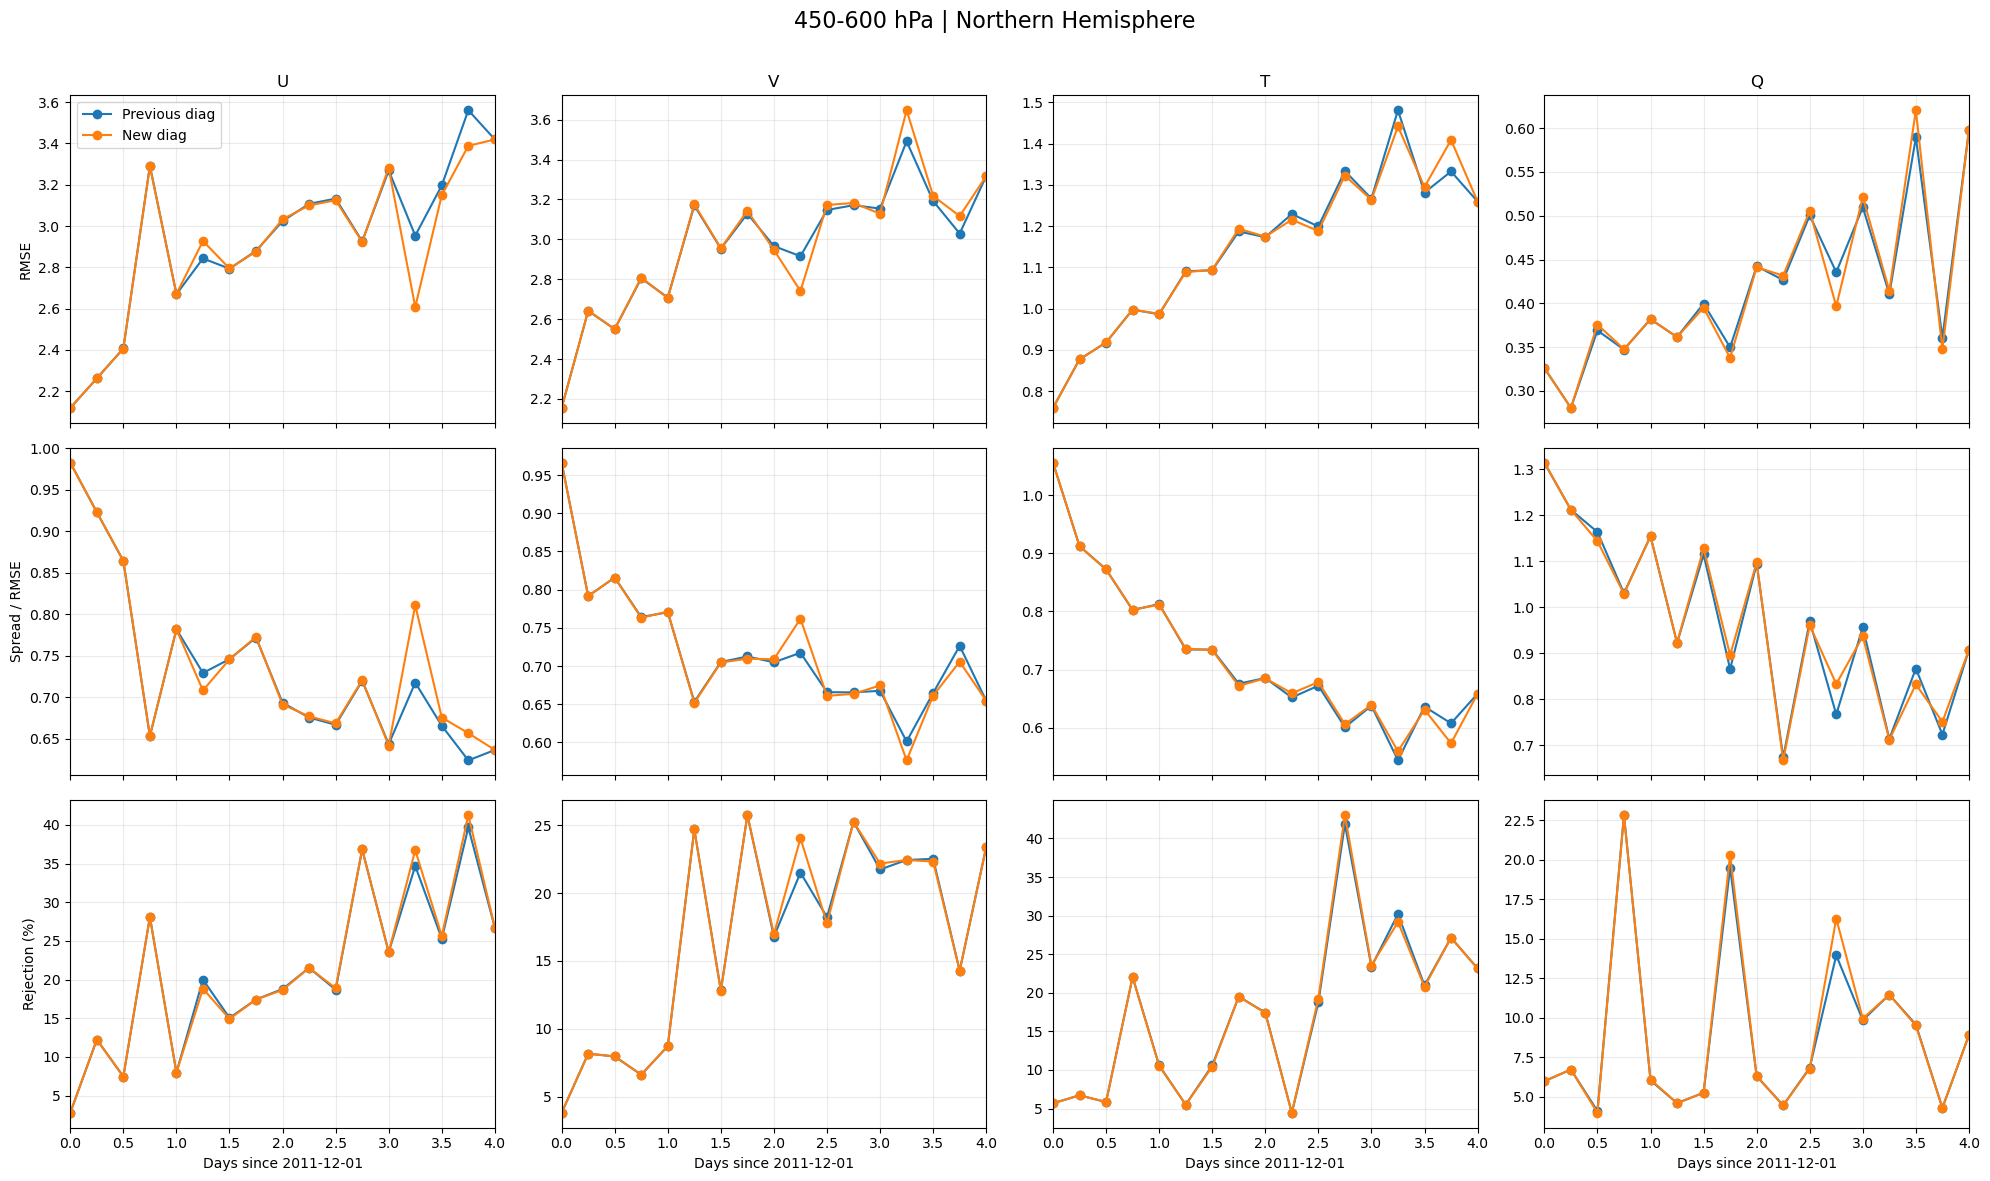

Saved /compyfs/www/zhan391/e3sm_dart/diag_out/figure/dart40_previous_vs_new/UVTQ_225-275hPa.pdf


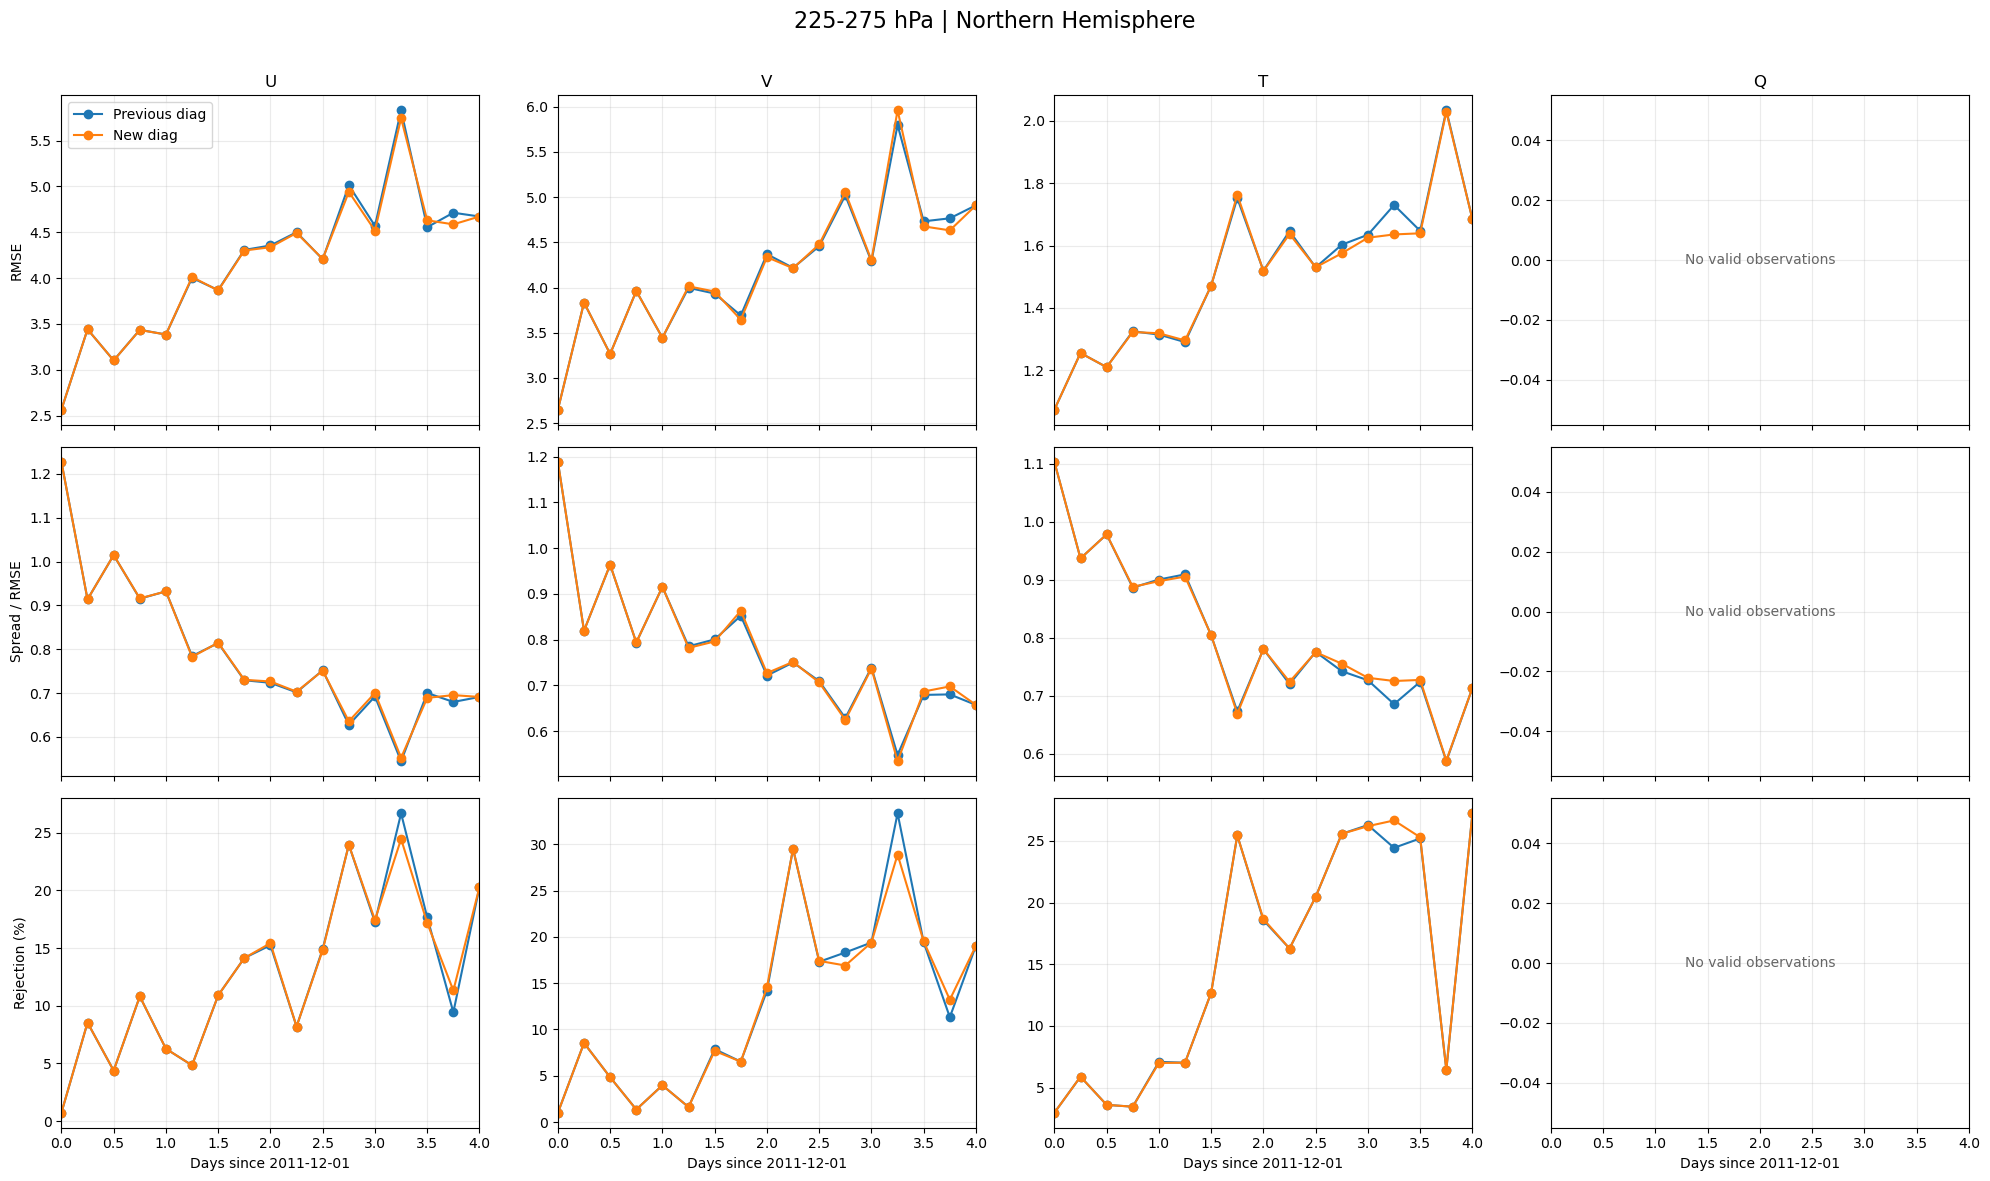

In [25]:
for level_label in PLOT_LEVELS:
    plot_level_comparison(level_label)
